In [3]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem

DF = pd.read_csv('SMILES_Inchikey_IR_LD50.csv')  # using DF per your preference

# Select IR columns (adjust the prefixes to match your file)
ir_B_cols = [c for c in DF if c.startswith("f")]
             
def morgan_bits(smiles, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return [0]*n_bits
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    return list(fp)  # 0/1 list

# Build ECFP DataFrame aligned by InChIKey
ecfp_list = [morgan_bits(smi) for smi in DF['SMILES']]
ecfp_cols = [f'ecfp_{i}' for i in range(len(ecfp_list[0]))]
ECFP = pd.DataFrame(ecfp_list, columns=ecfp_cols)
ECFP.insert(0, 'InChIKey', DF['InChIKey'])

# Merge IR + ECFP + LD50 safely by key
left = DF[['InChIKey', 'LD50'] + ir_B_cols]
COMBINED = left.merge(ECFP, on='InChIKey', how='inner')

# Save once if you want a frozen feature table
COMBINED.to_csv('Broaden_Group.csv', index=False)


[21:24:39] DEPRECATION WARNING: please use MorganGenerator
[21:24:39] DEPRECATION WARNING: please use MorganGenerator
[21:24:39] DEPRECATION WARNING: please use MorganGenerator
[21:24:39] DEPRECATION WARNING: please use MorganGenerator
[21:24:39] DEPRECATION WARNING: please use MorganGenerator
[21:24:39] DEPRECATION WARNING: please use MorganGenerator
[21:24:39] DEPRECATION WARNING: please use MorganGenerator
[21:24:39] DEPRECATION WARNING: please use MorganGenerator
[21:24:39] DEPRECATION WARNING: please use MorganGenerator
[21:24:39] DEPRECATION WARNING: please use MorganGenerator
[21:24:39] DEPRECATION WARNING: please use MorganGenerator
[21:24:39] DEPRECATION WARNING: please use MorganGenerator
[21:24:39] DEPRECATION WARNING: please use MorganGenerator
[21:24:39] DEPRECATION WARNING: please use MorganGenerator
[21:24:39] DEPRECATION WARNING: please use MorganGenerator
[21:24:39] DEPRECATION WARNING: please use MorganGenerator
[21:24:39] DEPRECATION WARNING: please use MorganGenerat

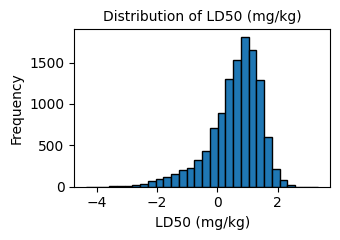

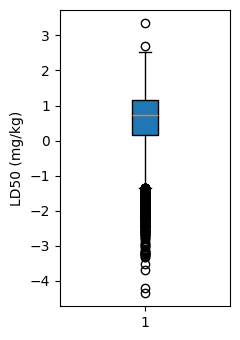

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

DF = pd.read_csv("Broaden_Group.csv")

# Histogram (journal one-column size)
plt.figure(figsize=(3.5, 2.5))
plt.hist(DF["LD50"], bins=30, edgecolor="black")
plt.xlabel("LD50 (mg/kg)")
plt.ylabel("Frequency")
plt.title("Distribution of LD50 (mg/kg)", fontsize=10)
plt.tight_layout()
plt.savefig("ld50_histogram.png", dpi=600)
plt.show()

# Boxplot (journal one-column size)
plt.figure(figsize=(2.5, 3.5))
plt.boxplot(DF["LD50"], vert=True, patch_artist=True)
plt.ylabel("LD50 (mg/kg)")
plt.tight_layout()
plt.savefig("ld50_boxplot.png", dpi=600)
plt.show()


In [3]:
#==NEW VERSION===
# 1) Coerce everything that should be numeric
IR_B_num = COMBINED[ir_B_cols].apply(pd.to_numeric, errors='coerce')
FP_num = COMBINED[fp_cols].apply(pd.to_numeric, errors='coerce')  # safe even if already 0/1
y_num  = pd.to_numeric(COMBINED['LD50'], errors='coerce')

# 2) Build ONE joint validity mask (keep rows where ALL are non-NaN)
mask = IR_B_num.notna().all(axis=1) & FP_num.notna().all(axis=1) & y_num.notna()

# Optional: see how many you drop
n_before = len(COMBINED)
n_after  = int(mask.sum())
print(f"Dropping {n_before - n_after} of {n_before} rows ({(n_before - n_after)/n_before:.1%}).")

# 3) Apply the SAME mask to every block, then convert
IR_B = IR_B_num.loc[mask].to_numpy(dtype=np.float64)
FP = FP_num.loc[mask].to_numpy(dtype=np.float64)
y  = y_num.loc[mask].to_numpy(dtype=np.float64)

NameError: name 'COMBINED' is not defined

In [1]:
import numpy as np
import pandas as pd
import re
# If not in memory
COMBINED = pd.read_csv('Broaden_Group.csv')

ir_B_cols = [c for c in COMBINED.columns if c.startswith("f")]
fp_cols  = [c for c in COMBINED.columns if c.startswith('ecfp_')]

IR_B = COMBINED[ir_B_cols].apply(pd.to_numeric, errors='coerce').to_numpy(dtype=np.float64)
FP = COMBINED[fp_cols].to_numpy(dtype=np.float64)
y  = pd.to_numeric(COMBINED['LD50'], errors='coerce').to_numpy(dtype=np.float64)

def check(name, X, cols=None):
    n_nan = np.isnan(X).sum()
    n_inf = np.isinf(X).sum()
    print(f"{name}: shape={X.shape} nan={n_nan} inf={n_inf}")
    if cols is not None and (n_nan>0 or n_inf>0):
        bad_cols = np.array(cols)[~np.isfinite(X).all(axis=0)]
        print(f"  bad columns (first 20): {list(bad_cols)[:20]}")

check("IR_B", IR_B, ir_B_cols)
check("FP", FP, fp_cols)
check("y",  y)


IR_B: shape=(11772, 2520) nan=0 inf=0
FP: shape=(11772, 2048) nan=0 inf=0
y: shape=(11772,) nan=0 inf=0


/home3/slsr63/myjupyterenv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2999: RuntimeWarning: divide by zero encountered in divide
  c /= stddev[:, None]
/home3/slsr63/myjupyterenv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home3/slsr63/myjupyterenv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3000: RuntimeWarning: divide by zero encountered in divide
  c /= stddev[None, :]
/home3/slsr63/myjupyterenv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


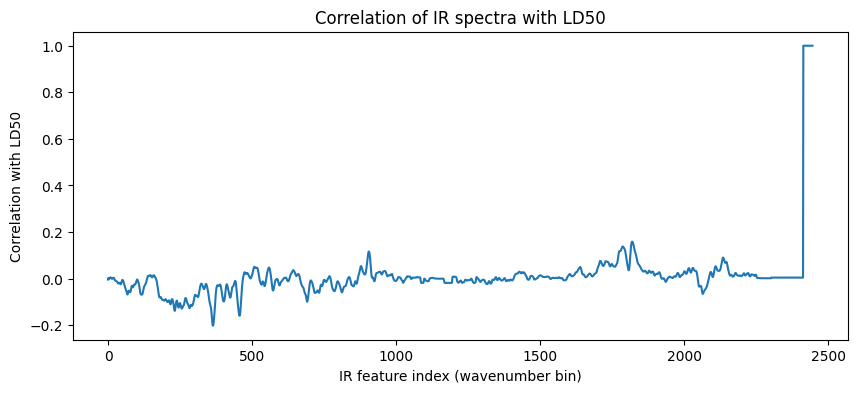

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


correlations = [np.corrcoef(IR_B[:, i], y)[0, 1] for i in range(IR_B.shape[1])]

plt.figure(figsize=(10,4))
plt.plot(range(len(correlations)), correlations)
plt.xlabel("IR feature index (wavenumber bin)")
plt.ylabel("Correlation with LD50")
plt.title("Correlation of IR spectra with LD50")
plt.show()


In [2]:
last_col = IR_B[:, -1]
print("Unique values:", np.unique(last_col)[:10])
print("Min:", last_col.min(), "Max:", last_col.max())
print("Std:", last_col.std())


Unique values: [0.]
Min: 0.0 Max: 0.0
Std: 0.0


In [3]:
import numpy as np

# Standard deviation of each column
stds = IR_B.std(axis=0)

# Find constant columns
const_cols = np.where(stds == 0)[0]

print("Constant columns (indices):", const_cols[:20])  # show first 20 if many
print("Total constant columns:", len(const_cols))

##dur to the underflow happen between col 2413 to 2432, drop them since tehy carry no info 

Constant columns (indices): [2413 2414 2415 2416 2417 2418 2419 2420 2421 2422 2423 2424 2425 2426
 2427 2428 2429 2430 2431 2432]
Total constant columns: 107


In [4]:
for idx in const_cols[:5]:  # first 5 constant bins
    vals = np.unique(IR_B[:, idx])
    print(ir_B_cols[idx], vals)

f2413 [0.00000000e+000 6.60099578e-163]
f2414 [0.00000000e+000 6.67752986e-167]
f2415 [0.00000000e+000 6.03164035e-171]
f2416 [0.00000000e+000 4.86483655e-175]
f2417 [0.00000000e+000 3.50359812e-179]


In [7]:
col_idx = ir_B_cols.index("f2519")  # or use np.where
vals = IR_B[:, col_idx]

print("f2520 min:", vals.min())
print("f2520 max:", vals.max())
print("f2520 unique (sample):", np.unique(vals)[:20])
print("f2520 nonzero count:", np.count_nonzero(vals))


f2520 min: 0.0
f2520 max: 0.0
f2520 unique (sample): [0.]
f2520 nonzero count: 0


In [8]:
import numpy as np

stds = IR_B.std(axis=0)
keep_mask = stds > 0
IR_B_clean = IR_B[:, keep_mask]
ir_B_cols_clean = [c for c,k in zip(ir_B_cols, keep_mask) if k]


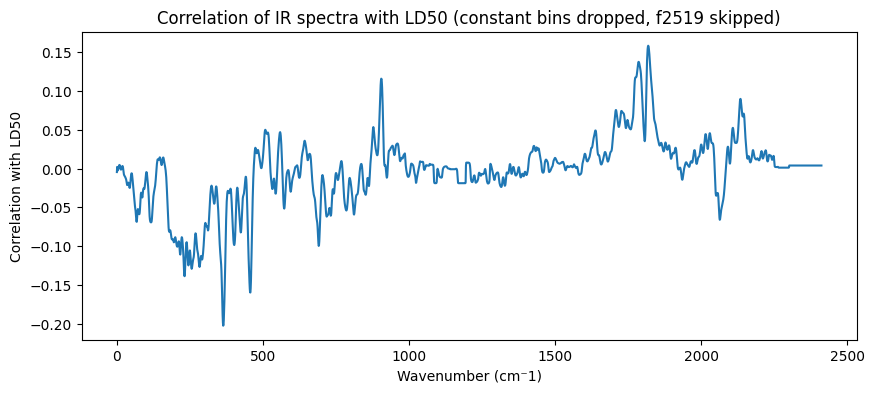

In [10]:
#FINAL DATA

import numpy as np
import matplotlib.pyplot as plt
import re

# Suppose you already have:
# IR_B_clean  -> NumPy array with constant bins removed
# ir_B_cols_clean -> matching list of names for IR_B_clean
# y -> LD50 array

# 1. Skip f2519 if present
skip_bin = "f2519"
mask = [c != skip_bin for c in ir_B_cols_clean]

IR_B_final = IR_B_clean[:, mask]
ir_B_cols_final = [c for c in ir_B_cols_clean if c != skip_bin]

# 2. Compute correlations safely
correlations = []
for i in range(IR_B_final.shape[1]):
    col = IR_B_final[:, i]
    if np.std(col) == 0:
        correlations.append(0.0)
    else:
        correlations.append(np.corrcoef(col, y)[0, 1])

# 3. Use actual wavenumber labels on the x-axis (nicer than index)
wn = np.array([int(re.search(r"\d+", c).group()) for c in ir_B_cols_final])
order = np.argsort(wn)  # make sure they’re sorted by wavenumber

plt.figure(figsize=(10, 4))
plt.plot(wn[order], np.array(correlations)[order])
plt.xlabel("Wavenumber (cm⁻1)")
plt.ylabel("Correlation with LD50")
plt.title("Correlation of IR spectra with LD50 (constant bins dropped, f2519 skipped)")
plt.show()
#The correlations now look much more like the raw IR map (same general shape).
#The artificial spike is gone, leaving only features that actually vary across molecules.
#This makes the broadened data consistent with the raw baseline, while still benefiting from broadening (smoother, less sparse).

In [ ]:
#Dropping constant (zero-variance) bins is not a loss of chemical information
#since those bins never carry signal across molecules. Instead, they introduce numerical artifacts
#(undefined correlations, artificial spikes, wasted dimensions).
#Removing them restores a correlation structure that resembles the raw data, but with the added smoothness of the broadened representation.

In [3]:
###SPLIT
import numpy as np
import pandas as pd
import re
from sklearn.model_selection import train_test_split

# --- Load ---
COMBINED = pd.read_csv("Broaden_Group.csv")

# --- Column selection ---
ir_B_cols = [c for c in COMBINED.columns if c.startswith("f")]
fp_cols   = [c for c in COMBINED.columns if c.startswith("ecfp_")]

# --- Coerce numerics ---
IR_B = COMBINED[ir_B_cols].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=np.float64)
FP   = COMBINED[fp_cols].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=np.float64)
y    = pd.to_numeric(COMBINED["LD50"], errors="coerce").to_numpy(dtype=np.float64)

# --- Joint row mask: keep only fully finite rows across IR/FP/y ---
row_mask = np.isfinite(y) & np.isfinite(IR_B).all(axis=1) & np.isfinite(FP).all(axis=1)
IR_B, FP, y = IR_B[row_mask], FP[row_mask], y[row_mask]

# --- (Optional) clip ultra-tiny underflow to zero for stability (doesn't change ML) ---
# IR_B[IR_B < 1e-15] = 0.0

# --- Drop constant IR bins (zero variance after row filtering) ---
col_stds = IR_B.std(axis=0)
keep_ir_cols_mask = col_stds > 0.0
IR_B_clean = IR_B[:, keep_ir_cols_mask]
ir_B_cols_clean = [c for c, keep in zip(ir_B_cols, keep_ir_cols_mask) if keep]

print(f"IR_B clean shape: {IR_B_clean.shape}  (dropped {np.size(col_stds) - keep_ir_cols_mask.sum()} constant bins)")
print(f"FP shape: {FP.shape}")
print(f"y shape: {y.shape}")

# --- 70/15/15 split ---
n = len(y)
idx = np.arange(n)

# test 15%
train_idx, test_idx = train_test_split(idx, test_size=0.15, random_state=42)

# validation 15% of total (i.e., 15/85 of the remaining)
train_idx, val_idx = train_test_split(train_idx, test_size=0.15/0.85, random_state=42)

# --- Slice arrays ---
IR_B_tr, IR_B_val, IR_B_te = IR_B_clean[train_idx], IR_B_clean[val_idx], IR_B_clean[test_idx]
FP_tr,   FP_val,   FP_te   = FP[train_idx],         FP[val_idx],         FP[test_idx]
y_tr,    y_val,    y_te    = y[train_idx],          y[val_idx],          y[test_idx]

print("Train shapes :", IR_B_tr.shape, FP_tr.shape, y_tr.shape)
print("Val shapes   :", IR_B_val.shape, FP_val.shape, y_val.shape)
print("Test shapes  :", IR_B_te.shape, FP_te.shape, y_te.shape)

# If you need the kept IR column names for later (e.g., feature importances):
# ir_B_cols_clean -> corresponds to IR_B_* columns in this same order.


IR_B clean shape: (11772, 2413)  (dropped 107 constant bins)
FP shape: (11772, 2048)
y shape: (11772,)
Train shapes : (8240, 2413) (8240, 2048) (8240,)
Val shapes   : (1766, 2413) (1766, 2048) (1766,)
Test shapes  : (1766, 2413) (1766, 2048) (1766,)


In [6]:
#=====SVR======

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV


In [9]:
#SVR-IR_B

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# --- Baseline model on validation ---
baseline = make_pipeline(StandardScaler(), SVR())
baseline.fit(IR_B_tr, y_tr)
val_pred = baseline.predict(IR_B_val)
print("Baseline Val -> R2=%.4f MAE=%.4f RMSE=%.4f" % (
    r2_score(y_val, val_pred),
    mean_absolute_error(y_val, val_pred),
    mean_squared_error(y_val, val_pred)
))

Baseline Val -> R2=0.3464 MAE=0.5023 RMSE=0.4945


In [10]:
# === Efficient SVR(RBF) hyperparameter tuning for large IR_B ===
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import loguniform, uniform

# Successive halving
from sklearn.experimental import enable_halving_search_cv  # noqa: F401
from sklearn.model_selection import HalvingRandomSearchCV

# Clean inputs (train/val are assumed to be IR_B_tr, IR_B_val, y_tr, y_val)
IR_B_tr  = np.nan_to_num(IR_B_tr.astype(np.float32),  nan=0.0, posinf=0.0, neginf=0.0)
IR_B_val = np.nan_to_num(IR_B_val.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)
y_tr     = y_tr.astype(np.float32)
y_val    = y_val.astype(np.float32)

pipe = make_pipeline(
    StandardScaler(with_mean=True, with_std=True),
    SVR(kernel="rbf", gamma="scale", cache_size=2000)
)

param_dist = {
    "svr__C": loguniform(1e-1, 1e2),     # tighter, faster, usually sufficient with gamma='scale'
    "svr__epsilon": uniform(1e-3, 0.3),  # ~[0.001, 0.301]
}

halving = HalvingRandomSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    factor=3,                               # stronger pruning => faster
    resource="n_samples",                   # grow #samples each round
    max_resources=IR_B_tr.shape[0],
    min_resources=max(256, int(0.1*IR_B_tr.shape[0])),  # start small
    cv=3,                                   # fewer folds for speed
    n_candidates="exhaust",                 # evaluate all drawn candidates per rung
    n_jobs=-1,
    scoring="r2",
    random_state=42,
    verbose=1,
    refit=True
)

# Tune on TRAIN only
halving.fit(IR_B_tr, y_tr)

print("Best params:", halving.best_params_)
print("Best CV R2: %.4f" % halving.best_score_)


n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 3
min_resources_: 824
max_resources_: 8240
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 10
n_resources: 824
Fitting 3 folds for each of 10 candidates, totalling 30 fits
----------
iter: 1
n_candidates: 4
n_resources: 2472
Fitting 3 folds for each of 4 candidates, totalling 12 fits
----------
iter: 2
n_candidates: 2
n_resources: 7416
Fitting 3 folds for each of 2 candidates, totalling 6 fits
Best params: {'svr__C': np.float64(6.358358856676251), 'svr__epsilon': np.float64(0.21342177333881365)}
Best CV R2: 0.3396


In [11]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Best hyperparameters from search
best_C = float(6.358358856676251)
best_eps = float(0.21342177333881365)

# Combine train + val
X_trainval = np.vstack([IR_B_tr, IR_B_val])
y_trainval = np.concatenate([y_tr, y_val])

# Build final SVR pipeline
final_model = make_pipeline(
    StandardScaler(),
    SVR(kernel="rbf", gamma="scale", C=best_C, epsilon=best_eps, cache_size=2000)
)

# Fit on train+val
final_model.fit(X_trainval, y_trainval)

# Evaluate on test set
y_pred_test = final_model.predict(IR_B_te)


In [21]:
r2   = r2_score(y_te, y_pred_test)
mae  = mean_absolute_error(y_te, y_pred_test)
rmse = mean_squared_error(y_te, y_pred_test)

print("\n=== Final SVR (RBF) on Test ===")
print(f"Best params: C={best_C:.4f}, epsilon={best_eps:.4f}, gamma='scale'")
print(f"R2   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")



=== Final SVR (RBF) on Test ===
Best params: C=6.3584, epsilon=0.2134, gamma='scale'
R2   : 0.4181
MAE  : 0.4809
RMSE : 0.4166


In [ ]:
#=====XGB=====

In [23]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone
from xgboost import XGBRegressor
import joblib

# --- IR_B-only XGB pipeline ---
IR_B_xgb_pipe = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("var", VarianceThreshold(0.0)),   # drop constant features
    ("scaler", StandardScaler()),      # trees don't need scaling, but harmless
    ("xgb", XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        objective="reg:squarederror"
    ))
])

# ---------- 1) Train -> Validate ----------
model_val = clone(IR_B_xgb_pipe)
model_val.fit(IR_B_tr, y_tr)

y_pred_val = model_val.predict(IR_B_val)
mae_val  = mean_absolute_error(y_val, y_pred_val)
rmse_val = mean_squared_error(y_val, y_pred_val)
r2_val   = r2_score(y_val, y_pred_val)

print("\nIR_B-only XGB (Validation)")
print(f"  MAE : {mae_val:.4f}")
print(f"  RMSE: {rmse_val:.4f}")
print(f"  R^2 : {r2_val:.4f}")


IR_B-only XGB (Validation)
  MAE : 0.4774
  RMSE: 0.4265
  R^2 : 0.4363


In [ ]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from copy import deepcopy

rng = np.random.default_rng(42)

# 1) Preprocessor (fit ONLY on train; reuse for val/test)
preproc = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("var", VarianceThreshold(0.0)),
])

X_tr_t  = preproc.fit_transform(IR_B_tr)   # y_tr not used by these steps
X_val_t = preproc.transform(IR_B_val)
X_te_t  = preproc.transform(IR_B_te)

# 2) Random param sampler (compact, robust ranges)
def sample_params(n=40, seed=42):
    r = np.random.default_rng(seed)
    out = []
    for _ in range(n):
        out.append({
            "learning_rate": float(10 ** r.uniform(-2.0, -0.7)),   # ~0.01–0.20 (log-uniform)
            "max_depth": int(r.integers(4, 13)),                   # 4–12
            "min_child_weight": float(10 ** r.uniform(0, 1.0)),    # 1–10 (log-uniform)
            "subsample": float(r.uniform(0.6, 1.0)),               # 0.6–1.0
            "colsample_bytree": float(r.uniform(0.3, 1.0)),        # 0.3–1.0
            "reg_alpha": float(10 ** r.uniform(-8, 1)),            # 1e-8–10 (log-uniform)
            "reg_lambda": float(10 ** r.uniform(0, 2)),            # 1–100 (log-uniform)
        })
    return out

candidates = sample_params(n=50, seed=42)  # adjust n for speed/quality

best = {
    "rmse_val": np.inf,
    "mae_val":  np.inf,
    "r2_val":  -np.inf,
    "params":   None,
    "best_iter": None,
}

# 3) Evaluate each config with early stopping on VAL (transformed arrays)
for i, p in enumerate(candidates, 1):
    xgb = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=5000,            # high cap; early stopping will trim
        random_state=42,
        n_jobs=-1,
        tree_method="hist",           # use "gpu_hist" if you have a GPU
        eval_metric="rmse",
        **p
    )

    xgb.fit(
        X_tr_t, y_tr,
        eval_set=[(X_val_t, y_val)],
        early_stopping_rounds=200,
        verbose=False
    )

    best_it = int(getattr(xgb, "best_iteration", xgb.n_estimators - 1))
    # Predict at best iteration (version-safe)
    try:
        y_val_hat = xgb.predict(X_val_t, iteration_range=(0, best_it + 1))
    except TypeError:
        y_val_hat = xgb.predict(X_val_t, ntree_limit=best_it + 1)

    mse  = mean_squared_error(y_val, y_val_hat)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_val, y_val_hat)
    r2   = r2_score(y_val, y_val_hat)

    if rmse < best["rmse_val"]:
        best.update({
            "rmse_val": rmse,
            "mae_val":  mae,
            "r2_val":   r2,
            "params":   deepcopy(p),
            "best_iter": best_it,
        })

    print(f"[{i:02d}/{len(candidates)}] val RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}  "
          f"best_iter={best_it}  params={p}")

print("\n=== Best on VALIDATION (IR_B-only XGB) ===")
print(f"Best RMSE : {best['rmse_val']:.4f}")
print(f"Best MAE  : {best['mae_val']:.4f}")
print(f"Best R^2  : {best['r2_val']:.4f}")
print(f"Best iter : {best['best_iter']}")
print(f"Best params: {best['params']}")

# 4) Refit preproc on TRAIN+VAL, then train final XGB with best_iter trees
preproc_final = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("var", VarianceThreshold(0.0)),
])
X_trval_t = preproc_final.fit_transform(np.vstack([IR_B_tr, IR_B_val]))
y_trval   = np.concatenate([y_tr, y_val])
X_te_t2   = preproc_final.transform(IR_B_te)

final = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=best["best_iter"] if best["best_iter"] is not None else 1000,
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
    **(best["params"] if best["params"] is not None else {})
)
final.fit(X_trval_t, y_trval, verbose=False)

# 5) Test metrics (R2 / RMSE / MAE)
y_te_hat = final.predict(X_te_t2)
mse_te  = mean_squared_error(y_te, y_te_hat)
rmse_te = np.sqrt(mse_te)
mae_te  = mean_absolute_error(y_te, y_te_hat)
r2_te   = r2_score(y_te, y_te_hat)

print("\n=== Test (held-out) with best config ===")
print(f"MAE : {mae_te:.4f}")
print(f"RMSE: {rmse_te:.4f}")
print(f"R^2 : {r2_te:.4f}")


In [24]:
# ---------- 2) Train+Val -> Test ----------
X_trainval = np.vstack([IR_B_tr, IR_B_val])
y_trainval = np.concatenate([y_tr, y_val])

model_test = clone(IR_B_xgb_pipe)
model_test.fit(X_trainval, y_trainval)

y_pred_test = model_test.predict(IR_B_te)
mae_te  = mean_absolute_error(y_te, y_pred_test)
rmse_te = mean_squared_error(y_te, y_pred_test)
r2_te   = r2_score(y_te, y_pred_test)

print("\nIR_B-only XGB (Test)")
print(f"  MAE : {mae_te:.4f}")
print(f"  RMSE: {rmse_te:.4f}")
print(f"  R^2 : {r2_te:.4f}")



IR_B-only XGB (Test)
  MAE : 0.4601
  RMSE: 0.3855
  R^2 : 0.4615


In [6]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from tensorflow.keras import regularizers


2025-09-04 15:28:39.278051: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-04 15:28:39.284879: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-04 15:28:39.295793: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-04 15:28:39.309665: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756996119.329473 1430055 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756996119.33

In [3]:
from sklearn.preprocessing import StandardScaler

# -----------------------------
# 1. Clean + scale IR_B only
# -----------------------------
IR_B_tr  = np.nan_to_num(IR_B_tr.astype(np.float32),  nan=0.0, posinf=0.0, neginf=0.0)
IR_B_val = np.nan_to_num(IR_B_val.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)
IR_B_te  = np.nan_to_num(IR_B_te.astype(np.float32),  nan=0.0, posinf=0.0, neginf=0.0)

FP_tr  = np.nan_to_num(FP_tr.astype(np.float32),  nan=0.0, posinf=0.0, neginf=0.0)
FP_val = np.nan_to_num(FP_val.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)
FP_te  = np.nan_to_num(FP_te.astype(np.float32),  nan=0.0, posinf=0.0, neginf=0.0)

y_tr  = y_tr.astype(np.float32)
y_val = y_val.astype(np.float32)
y_te  = y_te.astype(np.float32)

ir_scaler = StandardScaler()
IR_B_tr_s  = ir_scaler.fit_transform(IR_B_tr)
IR_B_val_s = ir_scaler.transform(IR_B_val)
IR_B_te_s  = ir_scaler.transform(IR_B_te)


In [4]:
# -----------------------------
# 1. Clean (Remove NaNs, Infs)
# -----------------------------
# Replace NaN, +Inf, -Inf values with zeros for IR_B and FP
IR_B_tr = np.nan_to_num(IR_B_tr.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)
IR_B_val = np.nan_to_num(IR_B_val.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)
IR_B_te = np.nan_to_num(IR_B_te.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)

FP_tr = np.nan_to_num(FP_tr.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)
FP_val = np.nan_to_num(FP_val.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)
FP_te = np.nan_to_num(FP_te.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)

# Ensure target variable is float32
y_tr = y_tr.astype(np.float32)
y_val = y_val.astype(np.float32)
y_te = y_te.astype(np.float32)

In [7]:
# -----------------------------
# 2. Early-fusion inputs (concat IR_B || ECFP)
# -----------------------------
X_tr_early  = np.concatenate([IR_B_tr,  FP_tr],  axis=1)
X_val_early = np.concatenate([IR_B_val, FP_val], axis=1)
X_te_early  = np.concatenate([IR_B_te,  FP_te],  axis=1)

# CNN expects (samples, timesteps, channels)
X_tr_cnn  = X_tr_early[..., np.newaxis]
X_val_cnn = X_val_early[..., np.newaxis]
X_te_cnn  = X_te_early[..., np.newaxis]

# -----------------------------
# 3. CNN model definition
# -----------------------------
def cnn_model(input_len):
    reg = regularizers.l2(1e-5)
    inp = layers.Input(shape=(input_len, 1))

    x = layers.Conv1D(64, kernel_size=17, padding="same",
                      activation=None, kernel_regularizer=reg)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.1)(x)

    # Dilated stack
    for d in [2, 4, 8]:
        skip = x
        x = layers.Conv1D(64, kernel_size=17, padding="same", dilation_rate=d,
                          activation=None, kernel_regularizer=reg)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.Conv1D(64, kernel_size=1, padding="same",
                          activation=None, kernel_regularizer=reg)(x)
        x = layers.Add()([x, skip])
        x = layers.Activation("relu")(x)
        x = layers.Dropout(0.1)(x)

    x = layers.Conv1D(128, kernel_size=33, padding="same", activation="relu",
                      kernel_regularizer=reg)(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation="relu", kernel_regularizer=reg)(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(1)(x)

    model = models.Model(inp, out)
    opt = tf.keras.optimizers.Adam(learning_rate=3e-4)
    model.compile(optimizer=opt, loss=tf.keras.losses.Huber(delta=1.0))
    return model

# -----------------------------
# 4. Train
# -----------------------------
model = cnn_model(X_tr_cnn.shape[1])
model.summary()

cbs = [
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                patience=5, min_lr=1e-6, verbose=1),
    callbacks.EarlyStopping(monitor="val_loss", patience=12,
                            restore_best_weights=True, verbose=1)
]

hist = model.fit(
    X_tr_cnn, y_tr,
    validation_data=(X_val_cnn, y_val),
    epochs=120,
    batch_size=64,
    callbacks=cbs,
    verbose=1
)

# -----------------------------
# 5. Evaluate
# -----------------------------
y_pred = model.predict(X_te_cnn, verbose=0).ravel()

r2 = r2_score(y_te, y_pred)
rmse = mean_squared_error(y_te, y_pred)
print(f"\nCNN (dilated early-fusion) on IR_B+ECFP")
print(f"  R2   : {r2:.4f}")
print(f"  RMSE : {rmse:.4f}")

E0000 00:00:1756996126.608625 1430055 cuda_executor.cc:1228] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1756996126.611602 1430055 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 4461, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 4461, 64)  │      1,152 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 4461, 64)  │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 4461, 64)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 4461, 64)  │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 4461, 64)  │     69,696 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4461, 64)  │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 4461, 64)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 4461, 64)  │      4,160 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 4461, 64)  │          0 │ conv1d_2[0][0],   │
│                     │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 4461, 64)  │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 4461, 64)  │          0 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 4461, 64)  │     69,696 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4461, 64)  │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 4461, 64)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 4461, 64)  │      4,160 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 4461, 64)  │          0 │ conv1d_4[0][0],   │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 4461, 64)  │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 4461, 64)  │          0 │ activation_4[0][… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 510,849 (1.95 MB)

 Trainable params: 510,337 (1.95 MB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/120
129/129 ━━━━━━━━━━━━━━━━━━━━ 1511s 12s/step - loss: 0.3153 - val_loss: 0.3180 - learning_rate: 3.0000e-04
Epoch 2/120
129/129 ━━━━━━━━━━━━━━━━━━━━ 1502s 12s/step - loss: 0.2993 - val_loss: 0.3241 - learning_rate: 3.0000e-04
Epoch 3/120
129/129 ━━━━━━━━━━━━━━━━━━━━ 1442s 11s/step - loss: 0.2989 - val_loss: 0.3304 - learning_rate: 3.0000e-04
Epoch 4/120
129/129 ━━━━━━━━━━━━━━━━━━━━ 1468s 11s/step - loss: 0.2938 - val_loss: 0.3691 - learning_rate: 3.0000e-04
Epoch 5/120
129/129 ━━━━━━━━━━━━━━━━━━━━ 1472s 11s/step - loss: 0.2928 - val_loss: 0.3095 - learning_rate: 3.0000e-04
Epoch 6/120
129/129 ━━━━━━━━━━━━━━━━━━━━ 1472s 11s/step - loss: 0.2840 - val_loss: 0.2875 - learning_rate: 3.0000e-04
Epoch 7/120
129/129 ━━━━━━━━━━━━━━━━━━━━ 1452s 11s/step - loss: 0.2789 - val_loss: 0.2814 - learning_rate: 3.0000e-04
Epoch 8/120
129/129 ━━━━━━━━━━━━━━━━━━━━ 1456s 11s/step - loss: 0.2743 - val_loss: 0.2810 - learning_rate: 3.0000e-04
Epoch 9/120
129/129 ━━━━━━━━━━━━━━━━━━━━ 1463s 11s/step 

In [ ]:
#!/usr/bin/env python3
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers, backend as K

# ------------------------------------------------------------
# 0) Build early-fusion inputs (IR_B || ECFP) and CNN tensors
# ------------------------------------------------------------
X_tr_early  = np.concatenate([IR_B_tr,  FP_tr],  axis=1)
X_val_early = np.concatenate([IR_B_val, FP_val], axis=1)
X_te_early  = np.concatenate([IR_B_te,  FP_te],  axis=1)

# CNN expects (samples, timesteps, channels=1)
X_tr_cnn  = X_tr_early[..., np.newaxis]
X_val_cnn = X_val_early[..., np.newaxis]
X_te_cnn  = X_te_early[..., np.newaxis]

# ------------------------------------------------------------
# 1) Model definition (your dilated early-fusion CNN)
# ------------------------------------------------------------
def cnn_model(input_len):
    reg = regularizers.l2(1e-5)
    inp = layers.Input(shape=(input_len, 1))

    x = layers.Conv1D(64, kernel_size=17, padding="same",
                      activation=None, kernel_regularizer=reg)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.1)(x)

    # Dilated residual stack
    for d in [2, 4, 8]:
        skip = x
        x = layers.Conv1D(64, kernel_size=17, padding="same", dilation_rate=d,
                          activation=None, kernel_regularizer=reg)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.Conv1D(64, kernel_size=1, padding="same",
                          activation=None, kernel_regularizer=reg)(x)
        x = layers.Add()([x, skip])
        x = layers.Activation("relu")(x)
        x = layers.Dropout(0.1)(x)

    x = layers.Conv1D(128, kernel_size=33, padding="same",
                      activation="relu", kernel_regularizer=reg)(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation="relu", kernel_regularizer=reg)(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(1)(x)

    model = models.Model(inp, out)

    # Compile with Huber loss + RMSE metric so we can plot val_rmse later
    opt = tf.keras.optimizers.Adam(learning_rate=3e-4)
    model.compile(optimizer=opt,
                  loss=tf.keras.losses.Huber(delta=1.0),
                  metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse")])
    return model

model = cnn_model(X_tr_cnn.shape[1])

# ------------------------------------------------------------
# 2) Callbacks: ReduceLROnPlateau / EarlyStopping (monitor val_rmse), CSV log, LR logger
# ------------------------------------------------------------
class LrLogger(callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        # Try both attributes for TF compatibility
        lr_attr = getattr(self.model.optimizer, "learning_rate", None)
        if lr_attr is None:
            lr_attr = getattr(self.model.optimizer, "lr", None)
        try:
            lr_val = float(K.get_value(lr_attr))
        except Exception:
            lr_val = float(lr_attr)
        logs["lr"] = lr_val
        # Also stash into History
        if hasattr(self.model, "history") and hasattr(self.model.history, "history"):
            self.model.history.history.setdefault("lr", []).append(lr_val)

cbs = [
    callbacks.ReduceLROnPlateau(monitor="val_rmse", factor=0.5,
                                patience=5, min_lr=1e-6, verbose=1),
    callbacks.EarlyStopping(monitor="val_rmse", patience=12,
                            restore_best_weights=True, verbose=1),
    callbacks.CSVLogger("early_fusion_history.csv", append=False),
    LrLogger(),
]

# ------------------------------------------------------------
# 3) Train
# ------------------------------------------------------------
history = model.fit(
    X_tr_cnn, y_tr,
    validation_data=(X_val_cnn, y_val),
    epochs=120,
    batch_size=64,
    callbacks=cbs,
    verbose=1
)

# ------------------------------------------------------------
# 4) Plot Validation RMSE curve (per epoch)
# ------------------------------------------------------------
val_rmse = history.history.get("val_rmse", None)
if val_rmse is None:
    raise RuntimeError("val_rmse not found in history. Ensure metrics=[RootMeanSquaredError(name='rmse')] in compile().")

plt.figure()
plt.plot(range(1, len(val_rmse)+1), val_rmse, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Validation RMSE")
plt.title("Validation Learning Curve (RMSE)")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.savefig("val_rmse_curve.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved plot: val_rmse_curve.png")

# ------------------------------------------------------------
# 5) Final metrics (Validation + Test) with correct RMSE
# ------------------------------------------------------------
# Validation (best epoch weights already restored)
y_val_pred = model.predict(X_val_cnn, verbose=0).ravel()
val_rmse_final = float(np.sqrt(mean_squared_error(y_val, y_val_pred)))
print(f"Final validation RMSE (best epoch): {val_rmse_final:.4f}")

# Test
y_te_pred = model.predict(X_te_cnn, verbose=0).ravel()
mse_te  = mean_squared_error(y_te, y_te_pred)
rmse_te = float(np.sqrt(mse_te))
mae_te  = mean_absolute_error(y_te, y_te_pred)
r2_te   = r2_score(y_te, y_te_pred)

print("\nCNN (dilated early-fusion) on IR_B+ECFP — Test set")
print(f"  R2   : {r2_te:.4f}")
print(f"  RMSE : {rmse_te:.4f}")
print(f"  MAE  : {mae_te:.4f}")


In [ ]:
# =============================
# 0) Imports & reproducibility
# =============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

np.random.seed(42)
tf.keras.utils.set_random_seed(42)

# =============================
# 1) Load & select columns
# =============================
CSV_PATH = "Broaden_Group.csv"   # <-- change if needed
COMBINED = pd.read_csv(CSV_PATH)

ir_cols = [c for c in COMBINED.columns if c.startswith("f")]
fp_cols = [c for c in COMBINED.columns if c.startswith("ecfp_")]
target_col = "LD50"

IR = COMBINED[ir_cols].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=np.float64)
FP = COMBINED[fp_cols].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=np.float64)
y  = pd.to_numeric(COMBINED[target_col], errors="coerce").to_numpy(dtype=np.float64)

# Keep only rows fully finite across all inputs/target
row_mask = np.isfinite(y) & np.isfinite(IR).all(axis=1) & np.isfinite(FP).all(axis=1)
IR, FP, y = IR[row_mask], FP[row_mask], y[row_mask]

# Drop constant IR bins (zero variance after filtering)
col_stds = IR.std(axis=0)
keep_ir = col_stds > 0.0
IR = IR[:, keep_ir]
ir_cols_clean = [c for c, k in zip(ir_cols, keep_ir) if k]

print(f"After cleaning: IR {IR.shape}, FP {FP.shape}, y {y.shape}", flush=True)

# =============================
# 2) 70/15/15 split (fixed seed)
# =============================
n = len(y)
idx = np.arange(n)
train_idx, test_idx = train_test_split(idx, test_size=0.15, random_state=42)
train_idx, val_idx  = train_test_split(train_idx, test_size=0.15/0.85, random_state=42)

IR_tr, IR_val, IR_te = IR[train_idx], IR[val_idx], IR[test_idx]
FP_tr, FP_val, FP_te = FP[train_idx], FP[val_idx], FP[test_idx]
y_tr,  y_val,  y_te  = y[train_idx],  y[val_idx],  y[test_idx]

# =============================
# 3) Scale IR ONLY (fit on train), keep ECFP raw/binary
# =============================
ir_scaler = StandardScaler()
IR_tr_s  = ir_scaler.fit_transform(IR_tr.astype(np.float32))
IR_val_s = ir_scaler.transform(IR_val.astype(np.float32))
IR_te_s  = ir_scaler.transform(IR_te.astype(np.float32))

# CNN expects 3D input: (N, L, 1)
X_ir_tr  = IR_tr_s[..., None]
X_ir_val = IR_val_s[..., None]
X_ir_te  = IR_te_s[..., None]

# ECFPs: keep raw (0/1)
X_fp_tr  = FP_tr.astype('float32')
X_fp_val = FP_val.astype('float32')
X_fp_te  = FP_te.astype('float32')

# Targets
y_tr_  = y_tr.astype('float32')
y_val_ = y_val.astype('float32')
y_te_  = y_te.astype('float32')

# =============================
# 4) Build model (late fusion CNN + MLP)
# =============================
L2 = 1e-4
LR = 1e-3

# IR branch
ir_in = keras.Input(shape=(X_ir_tr.shape[1], 1), name='ir')
x = layers.GaussianNoise(0.01)(ir_in)
x = layers.Conv1D(64, 7, padding='same', use_bias=False, kernel_regularizer=regularizers.l2(L2))(x)
x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x); x = layers.MaxPool1D(2)(x)

x = layers.Conv1D(64, 7, padding='same', use_bias=False, kernel_regularizer=regularizers.l2(L2))(x)
x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x); x = layers.MaxPool1D(2)(x)

x = layers.Conv1D(128, 5, padding='same', use_bias=False, kernel_regularizer=regularizers.l2(L2))(x)
x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
x = layers.GlobalAveragePooling1D()(x)

x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(L2))(x)
x = layers.Dropout(0.30)(x)
ir_repr = layers.LayerNormalization()(x)

# FP branch
fp_in = keras.Input(shape=(X_fp_tr.shape[1],), name='ecfp')
y_ = layers.BatchNormalization()(fp_in)
y_ = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(L2))(y_)
y_ = layers.Dropout(0.30)(y_)
y_ = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(L2))(y_)
fp_repr = layers.LayerNormalization()(y_)

# Fusion + head
z = layers.Concatenate()([ir_repr, fp_repr])
z = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(L2))(z)
z = layers.Dropout(0.30)(z)
z = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(L2))(z)
out = layers.Dense(1)(z)

model = keras.Model(inputs=[ir_in, fp_in], outputs=out)
opt = keras.optimizers.Adam(learning_rate=LR, clipnorm=1.0)
# Use Huber loss, no extra metrics (we'll compute RMSE ourselves)
model.compile(optimizer=opt, loss=keras.losses.Huber(delta=0.5))
model.summary()

# =============================
# 5) Callback to log validation RMSE per epoch
# =============================
class ValRMSE(callbacks.Callback):
    def __init__(self, x_val, y_val, eval_every=1):
        super().__init__()
        self.x_val = x_val
        self.y_val = np.asarray(y_val).reshape(-1)
        self.eval_every = int(eval_every)
        self.epochs, self.val_rmse = [], []

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.eval_every != 0:
            return
        y_pred = self.model.predict(self.x_val, verbose=0).squeeze()
        y_pred = np.asarray(y_pred).reshape(-1)
        rmse = float(np.sqrt(mean_squared_error(self.y_val, y_pred)))
        self.epochs.append(epoch + 1)
        self.val_rmse.append(rmse)

val_logger = ValRMSE(
    x_val={'ir': X_ir_val, 'ecfp': X_fp_val},
    y_val=y_val_,
    eval_every=1
)

# =============================
# 6) Train
# =============================
cb = [
    callbacks.EarlyStopping(monitor='val_loss', mode='min', patience=8, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', mode='min', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    callbacks.ModelCheckpoint('best_fusion.keras', monitor='val_loss', mode='min', save_best_only=True),
    val_logger
]

model.fit(
    {'ir': X_ir_tr, 'ecfp': X_fp_tr}, y_tr_,
    validation_data=({'ir': X_ir_val, 'ecfp': X_fp_val}, y_val_),
    epochs=100, batch_size=128, callbacks=cb, verbose=1
)

# =============================
# 7) Plot validation RMSE curve (RMSE only)
# =============================
if len(val_logger.epochs) > 0:
    plt.figure()
    plt.plot(val_logger.epochs, val_logger.val_rmse)
    plt.xlabel('Epoch'); plt.ylabel('RMSE');
    plt.tight_layout()
    plt.savefig('val_rmse_vs_epoch.png', dpi=200)

    # Save raw values (epoch, RMSE only)
    try:
        pd.DataFrame({
            'epoch': val_logger.epochs,
            'val_rmse': val_logger.val_rmse
        }).to_csv('val_rmse_per_epoch.csv', index=False)
    except Exception:
        pass

    print("Saved: val_rmse_vs_epoch.png, val_rmse_per_epoch.csv")

# =============================
# 8) Final evaluation (RMSE only) + bar chart
# =============================
def report_rmse(xir, xfp, y_true, name):
    y_pred = model.predict({'ir': xir, 'ecfp': xfp}, verbose=0).squeeze()
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    print(f"{name:>5} | RMSE: {rmse:.4f}")
    return {'split': name.strip(), 'RMSE': rmse}

m_tr  = report_rmse(X_ir_tr,  X_fp_tr,  y_tr_,  "Train")
m_val = report_rmse(X_ir_val, X_fp_val, y_val_, " Val ")
m_te  = report_rmse(X_ir_te,  X_fp_te,  y_te_,  "Test")

